In [1]:
import os
import sys

In [2]:
from contextlib import redirect_stdout, redirect_stderr

In [3]:
import logging

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
sys.path.append('/home/olley/packages/polymer-master')

In [5]:
from polymer.main import run_atm_corr
from polymer.level1_netcdf import Level1_NETCDF
from polymer.level2_nc import Level2_NETCDF
from polymer.ancillary import Ancillary_NASA

In [6]:
DATA_DIR = '../data/'
results_dir = os.path.join(DATA_DIR, "s2_processed")
dir_content = os.listdir(results_dir)

In [7]:
log_file = 'polymer_run.log'
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler(log_file, mode='a')]
)
logger = logging.getLogger(__name__)

In [8]:
from netCDF4 import Dataset

In [9]:
with Dataset(os.path.join(DATA_DIR, 's2_processed/31UCS/subset-31UCS.nc'), 'r+') as ds:
    ds.setncattr('product_type', 'S2_MSI_Level-1C')

In [10]:
with Dataset(os.path.join(DATA_DIR, 's2_processed/30UXB/subset-30UXB.nc'), 'r+') as ds:
    ds.setncattr('product_type', 'S2_MSI_Level-1C')

In [11]:
dir_content

['.ipynb_checkpoints', '30UXB', '31UCS', '30UUB']

In [ ]:
for fn in dir_content:
    fp = os.path.join(results_dir, fn)  # fn is a tileId

    if fn not in ['.ipynb_checkpoints'] and os.path.isdir(fp):
        # Get S2 subset from SNAP output
        level1_file = os.path.join(results_dir, f'{fn}/subset-{fn}.nc')
        output_file = os.path.join(results_dir, f'{fn}/polymer-{fn}.nc')
        landmask_file = os.path.join(results_dir, f'{fn}/idepix-{fn}.nc')

        if os.path.exists(output_file):
            print(f"[{fn}] Skipping. Output file already exists.")
            continue

        try:
            # logger.info(f"[{fn}] Loading land mask file: {landmask_file}")
            # with xr.open_dataset(landmask_file) as ds:
            #     # land mask is 11th bit
            #     land_mask = (ds['pixel_classif_flags'].astype('int32') & 2**10) != 0
    
            # Process subset with Polymer
            
            logger.info(f"[{fn}] Loading Level 1: {level1_file}")    
            level1 = Level1_NETCDF(
                filename=level1_file,
                # landmask=land_mask,
                ancillary=Ancillary_NASA()
            )
    
            level2 = Level2_NETCDF(
                filename=output_file
            )

            print(f"[{fn}] Running Polymer...")
            logger.info(f"[{fn}] Running Polymer atmospheric correction...")

            with open(log_file, 'a') as f:
                with redirect_stdout(f), redirect_stderr(f):
                    run_atm_corr(
                        level1,
                        level2,
                        multiprocessing=-1
                    )
            logger.info(f"[{fn}] Atmospheric correction completed. Output saved to {output_file}")
        except Exception as e:
            print(f"[{fn}] Error processing: {e}")
            logger.info(f"[{fn}] Error processing")
            logger.info(repr(e))

MSI product, size is 2221x5490
[30UXB] Running Polymer...
MSI product, size is 4256x4848
Trying to download https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/GMAO_MERRA2.20250711T100000.MET.nc ... 
Trying to download https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/GMAO_MERRA2.20250711T110000.MET.nc ... 


2025-11-03 16:44:09 URL:https://oceandata.sci.gsfc.nasa.gov/getfile/GMAO_MERRA2.20250711T100000.MET.nc [3090360/3090360] -> "/home/olley/packages/polymer-master/polymer_ancillary/METEO/2025/192/GMAO_MERRA2.20250711T100000.MET.nc.tmp" [1]
2025-11-03 16:44:13 URL:https://oceandata.sci.gsfc.nasa.gov/getfile/GMAO_MERRA2.20250711T110000.MET.nc [3089443/3089443] -> "/home/olley/packages/polymer-master/polymer_ancillary/METEO/2025/192/GMAO_MERRA2.20250711T110000.MET.nc.tmp" [1]


[31UCS] Running Polymer...
MSI product, size is 3751x3492
Trying to download https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/GMAO_MERRA2.20240602T110000.MET.nc ... 
Trying to download https://oceandata.sci.gsfc.nasa.gov/cgi/getfile/GMAO_MERRA2.20240602T120000.MET.nc ... 


2025-11-03 16:54:47 URL:https://oceandata.sci.gsfc.nasa.gov/getfile/GMAO_MERRA2.20240602T110000.MET.nc [3167947/3167947] -> "/home/olley/packages/polymer-master/polymer_ancillary/METEO/2024/154/GMAO_MERRA2.20240602T110000.MET.nc.tmp" [1]
2025-11-03 16:54:51 URL:https://oceandata.sci.gsfc.nasa.gov/getfile/GMAO_MERRA2.20240602T120000.MET.nc [3161832/3161832] -> "/home/olley/packages/polymer-master/polymer_ancillary/METEO/2024/154/GMAO_MERRA2.20240602T120000.MET.nc.tmp" [1]


[30UUB] Running Polymer...


In [19]:
ds = xr.open_dataset(os.path.join(DATA_DIR, 's2_processed/32VPK/polymer-32VPK.nc'))

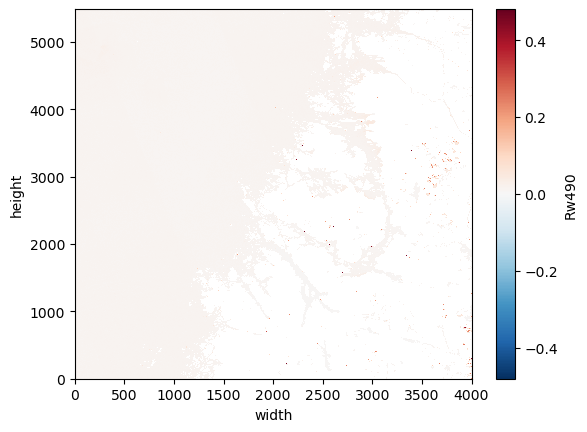

In [21]:
ds['Rw490'].plot()

In [15]:
ds_30UXB = xr.open_dataset(os.path.join(DATA_DIR, 's2_processed/30UXB/subset-30UXB.nc'))
ds_31UCS = xr.open_dataset(os.path.join(DATA_DIR, 's2_processed/31UCS/subset-31UCS.nc'))

In [16]:
ds_30UXB

<xarray.Dataset> Size: 5GB
Dimensions:                                 (y: 2221, x: 5490, tp_y: 5, tp_x: 9)
Coordinates:
    lat                                     (y, x) float64 98MB ...
    lon                                     (y, x) float64 98MB ...
Dimensions without coordinates: y, x, tp_y, tp_x
Data variables: (12/446)
    metadata                                int8 1B ...
    B1                                      (y, x) float64 98MB ...
    B2                                      (y, x) float64 98MB ...
    B3                                      (y, x) float64 98MB ...
    B4                                      (y, x) float64 98MB ...
    B5                                      (y, x) float64 98MB ...
    ...                                      ...
    nodata_B12_mask                         int8 1B ...
    partially_corrected_crosstalk_B12_mask  int8 1B ...
    saturated_l1a_B12_mask                  int8 1B ...
    opaque_clouds_mask                      int8 1B ...
    cirrus_clouds_mask                      int8 1B ...
    snow_and_ice_areas_mask                 int8 1B ...
Attributes:
    Conventions:       CF-1.4
    TileSize:          4096:4096
    metadata_profile:  beam
    metadata_version:  0.5
    auto_grouping:     sun:view:quality:ECMWF:tile:detector_footprint:nodata:...
    start_date:        10-AUG-2025 11:07:01.024000
    stop_date:         10-AUG-2025 11:07:01.024000
    product_type:      S2_MSI_Level-1C

In [17]:
ds_31UCS

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes:
    product_type:  S2_MSI_Level-1C